# AT&T : détecteur de spams par deep learning

**Objectif** : détecter automatiquement les SMS indésirables (*spam*) à partir de leur seul contenu.

**Démarche** (celle du cours sur l'embedding) :
1. Préparer les données : nettoyage, découpage train / validation / test, tokenisation avec `tiktoken`
2. Entraîner un premier modèle simple (embedding + moyenne + couche de sortie)
3. Entraîner un second modèle un peu plus riche (couche cachée + dropout)
4. Comparer les modèles sur la validation, puis mesurer le modèle retenu sur le jeu de test
5. Analyser les erreurs

## 1. Préparation des données

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### Chargement

Le fichier contient deux colonnes utiles : `v1` (`ham` = message normal, `spam`) et `v2` (le texte du SMS). Les trois autres colonnes sont vides.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1", usecols=["v1", "v2"])
df = df.rename(columns={"v1": "label", "v2": "text"})
print("Nombre de SMS :", len(df))
df.head()

Nombre de SMS : 5572


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Nettoyage

Le même SMS peut apparaître plusieurs fois. S'il se retrouve à la fois dans l'entraînement et dans le test, le modèle serait évalué sur des messages qu'il a déjà vus. On supprime donc les doublons.

In [3]:
print("Doublons :", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df["target"] = (df["label"] == "spam").astype(int)   # 1 = spam, 0 = ham
print("SMS après suppression des doublons :", len(df))
print()
print(df["label"].value_counts())
print(f"\nPart de spams : {df['target'].mean():.1%}")

Doublons : 403
SMS après suppression des doublons : 5169

label
ham     4516
spam     653
Name: count, dtype: int64

Part de spams : 12.6%


Les classes sont **déséquilibrées** : environ 1 SMS sur 8 est un spam. Un modèle qui répondrait toujours « ham » aurait donc déjà environ 87 % de bonnes réponses. L'*accuracy* seule n'est pas suffisante : on regardera aussi la **précision** (parmi les messages signalés spam, combien le sont vraiment) et le **rappel** (parmi les vrais spams, combien sont détectés).

### Découpage train / validation / test

70 % pour l'entraînement, 15 % pour la validation (choix du modèle) et 15 % pour le test (mesure finale). Le découpage est **stratifié** : chaque jeu garde la même part de spams.

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["target"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["target"], random_state=42)

for name, d in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:11s} {len(d):5d} SMS | part de spams : {d['target'].mean():.1%}")

train        3618 SMS | part de spams : 12.6%
validation    775 SMS | part de spams : 12.6%
test          776 SMS | part de spams : 12.6%


### Tokenisation

Comme dans le cours, on transforme chaque SMS en suite d'entiers avec `tiktoken` (tokenizer `cl100k_base`).

In [5]:
tokenizer = tiktoken.get_encoding("cl100k_base")

def encode_texts(texts):
    return [tokenizer.encode(text) for text in texts]

train_tokens = encode_texts(train_df["text"])
val_tokens = encode_texts(val_df["text"])
test_tokens = encode_texts(test_df["text"])

print(train_df["text"].iloc[0])
print(train_tokens[0][:15])

Why tired what special there you had
[10445, 19781, 1148, 3361, 1070, 499, 1047]


Pour construire des lots, toutes les séquences doivent avoir la même longueur. On regarde la distribution des longueurs pour choisir la longueur maximale : on retient celle qui couvre 95 % des SMS, les plus longs sont tronqués et les plus courts complétés avec des 0.

longueur moyenne : 21.9
longueur maximale : 186
longueur retenue (95e percentile) : 51


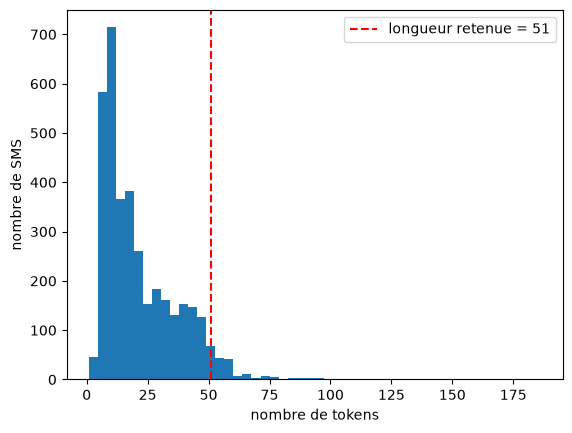

In [6]:
seq_lens = [len(seq) for seq in train_tokens]
print("longueur moyenne :", round(np.mean(seq_lens), 1))
print("longueur maximale :", np.max(seq_lens))

max_length = int(np.percentile(seq_lens, 95))
print("longueur retenue (95e percentile) :", max_length)

plt.hist(seq_lens, bins=50)
plt.axvline(max_length, color="red", linestyle="--", label=f"longueur retenue = {max_length}")
plt.xlabel("nombre de tokens")
plt.ylabel("nombre de SMS")
plt.legend()
plt.show()

In [7]:
def pad_sequences(sequences, max_length):
    return [seq[:max_length] + [0] * (max_length - len(seq)) for seq in sequences]

train_tokens = pad_sequences(train_tokens, max_length)
val_tokens = pad_sequences(val_tokens, max_length)
test_tokens = pad_sequences(test_tokens, max_length)

### Datasets et DataLoaders

In [8]:
class SpamDataset(Dataset):
    """Associe chaque SMS tokenisé (indices entiers) à son label (0 = ham, 1 = spam)."""

    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]


batch_size = 64
train_loader = DataLoader(SpamDataset(train_tokens, train_df["target"].values), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(SpamDataset(val_tokens, val_df["target"].values), batch_size=batch_size)
test_loader = DataLoader(SpamDataset(test_tokens, test_df["target"].values), batch_size=batch_size)

text, label = next(iter(train_loader))
print(text.shape, label.shape)

torch.Size([64, 51]) torch.Size([64])


## 2. Modèles

Il s'agit d'un problème de **classification binaire** : la sortie est un score unique, transformé en probabilité de spam par une sigmoïde. On utilise donc la perte `BCEWithLogitsLoss` (qui applique la sigmoïde en interne).

- **Modèle 1 (simple)** : couche d'embedding, moyenne des vecteurs des mots du SMS (sans compter les 0 de remplissage), puis une couche linéaire.
- **Modèle 2 (plus riche)** : même début, puis une couche cachée avec ReLU et du dropout pour limiter le sur-apprentissage.

In [9]:
vocab_size = tokenizer.n_vocab


class SpamClassifier(nn.Module):
    """Embedding -> moyenne des mots -> (couche cachée) -> score de spam."""

    def __init__(self, vocab_size, embed_dim, hidden_dim=None, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if hidden_dim is None:
            self.head = nn.Linear(embed_dim, 1)
        else:
            self.head = nn.Sequential(
                nn.Linear(embed_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 1),
            )

    def forward(self, x):
        embedded = self.embedding(x)                     # (lot, longueur, embed_dim)
        mask = (x != 0).unsqueeze(-1).float()            # 1 pour un vrai token, 0 pour le remplissage
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.head(pooled).squeeze(1)              # un score par SMS


model_1 = SpamClassifier(vocab_size, embed_dim=16).to(device)
model_2 = SpamClassifier(vocab_size, embed_dim=16, hidden_dim=32, dropout=0.3).to(device)
print(model_1)
print()
print(model_2)

SpamClassifier(
  (embedding): Embedding(100277, 16, padding_idx=0)
  (head): Linear(in_features=16, out_features=1, bias=True)
)

SpamClassifier(
  (embedding): Embedding(100277, 16, padding_idx=0)
  (head): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 3. Entraînement

La fonction d'entraînement suit celle du cours. À chaque époque, on mesure la perte et l'accuracy sur l'entraînement et sur la validation, et on garde les poids de l'époque où la perte de validation est la plus basse.

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += ((torch.sigmoid(logits) > 0.5).float() == labels).sum().item()
            n += len(labels)
    return total_loss / n, correct / n


def train(model, train_loader, val_loader, epochs=20, lr=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss, best_state = float("inf"), None

    for epoch in range(epochs):
        loss, acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history["loss"].append(loss); history["acc"].append(acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        if val_loss < best_val_loss:
            best_val_loss, best_state = val_loss, copy.deepcopy(model.state_dict())
        print(f"époque {epoch + 1:2d}/{epochs} | perte {loss:.4f} acc {acc:.3f} | validation : perte {val_loss:.4f} acc {val_acc:.3f}")

    model.load_state_dict(best_state)
    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(history["loss"], label="entraînement")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_title(f"{title} : perte"); axes[0].set_xlabel("époque"); axes[0].legend()
    axes[1].plot(history["acc"], label="entraînement")
    axes[1].plot(history["val_acc"], label="validation")
    axes[1].set_title(f"{title} : accuracy"); axes[1].set_xlabel("époque"); axes[1].legend()
    plt.tight_layout()
    plt.show()

### Modèle 1 : embedding + moyenne

époque  1/20 | perte 0.6175 acc 0.781 | validation : perte 0.5894 acc 0.823
époque  2/20 | perte 0.5621 acc 0.852 | validation : perte 0.5368 acc 0.858
époque  3/20 | perte 0.5052 acc 0.866 | validation : perte 0.4788 acc 0.866
époque  4/20 | perte 0.4429 acc 0.872 | validation : perte 0.4168 acc 0.872
époque  5/20 | perte 0.3792 acc 0.880 | validation : perte 0.3573 acc 0.885
époque  6/20 | perte 0.3208 acc 0.892 | validation : perte 0.3056 acc 0.895
époque  7/20 | perte 0.2715 acc 0.906 | validation : perte 0.2636 acc 0.906
époque  8/20 | perte 0.2316 acc 0.921 | validation : perte 0.2299 acc 0.916
époque  9/20 | perte 0.1994 acc 0.932 | validation : perte 0.2029 acc 0.919
époque 10/20 | perte 0.1735 acc 0.945 | validation : perte 0.1805 acc 0.933
époque 11/20 | perte 0.1520 acc 0.955 | validation : perte 0.1621 acc 0.945
époque 12/20 | perte 0.1343 acc 0.962 | validation : perte 0.1466 acc 0.948
époque 13/20 | perte 0.1196 acc 0.968 | validation : perte 0.1336 acc 0.952
époque 14/20

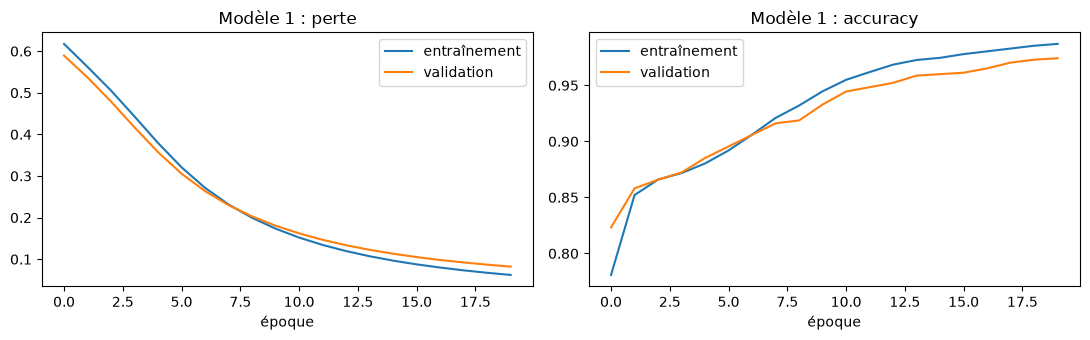

In [11]:
history_1 = train(model_1, train_loader, val_loader, epochs=20)
plot_history(history_1, "Modèle 1")

### Modèle 2 : avec couche cachée et dropout

époque  1/20 | perte 0.6352 acc 0.831 | validation : perte 0.5771 acc 0.874
époque  2/20 | perte 0.5052 acc 0.874 | validation : perte 0.4195 acc 0.874
époque  3/20 | perte 0.3582 acc 0.874 | validation : perte 0.2992 acc 0.874
époque  4/20 | perte 0.2752 acc 0.874 | validation : perte 0.2443 acc 0.874
époque  5/20 | perte 0.2249 acc 0.874 | validation : perte 0.2096 acc 0.874
époque  6/20 | perte 0.1915 acc 0.874 | validation : perte 0.1861 acc 0.874
époque  7/20 | perte 0.1699 acc 0.880 | validation : perte 0.1688 acc 0.886
époque  8/20 | perte 0.1502 acc 0.915 | validation : perte 0.1523 acc 0.942
époque  9/20 | perte 0.1277 acc 0.951 | validation : perte 0.1346 acc 0.959
époque 10/20 | perte 0.1083 acc 0.970 | validation : perte 0.1176 acc 0.963
époque 11/20 | perte 0.0875 acc 0.976 | validation : perte 0.1033 acc 0.965
époque 12/20 | perte 0.0740 acc 0.983 | validation : perte 0.0935 acc 0.964
époque 13/20 | perte 0.0642 acc 0.984 | validation : perte 0.0860 acc 0.965
époque 14/20

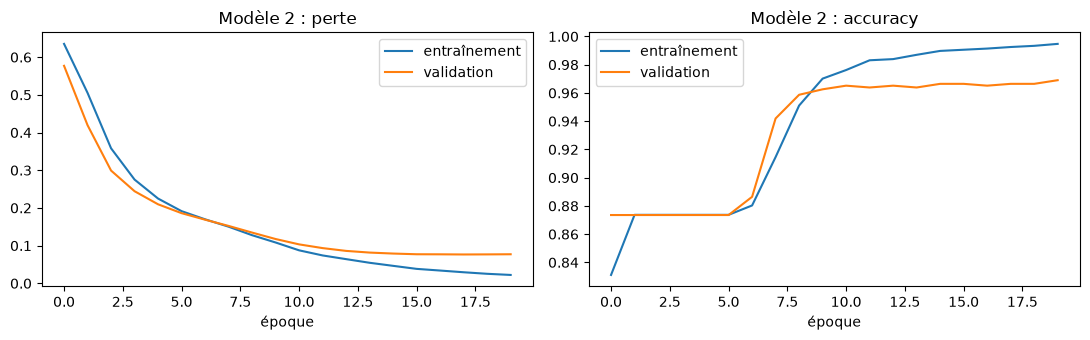

In [12]:
history_2 = train(model_2, train_loader, val_loader, epochs=20)
plot_history(history_2, "Modèle 2")

## 4. Évaluation

On calcule les prédictions de chaque modèle, avec un seuil de 0,5 : un SMS est classé spam si sa probabilité de spam dépasse 50 %.

Le **modèle retenu** est celui qui a le meilleur F1-score sur la **validation** (le F1 résume précision et rappel de la classe spam). Le jeu de test n'est utilisé qu'une fois, pour mesurer le modèle retenu.

In [13]:
def predict(model, loader):
    model.eval()
    probas, labels = [], []
    with torch.no_grad():
        for inputs, y in loader:
            probas.append(torch.sigmoid(model(inputs.to(device))).cpu())
            labels.append(y)
    return torch.cat(probas).numpy(), torch.cat(labels).numpy().astype(int)


def scores(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "précision (spam)": precision_score(y_true, y_pred, zero_division=0),
        "rappel (spam)": recall_score(y_true, y_pred),
        "F1 (spam)": f1_score(y_true, y_pred, zero_division=0),
    }


val_scores = {}
for name, model in [("Modèle 1", model_1), ("Modèle 2", model_2)]:
    probas, y_val = predict(model, val_loader)
    val_scores[name] = scores(y_val, (probas > 0.5).astype(int))

baseline = scores(y_val, np.zeros_like(y_val))
val_scores["Toujours « ham » (référence)"] = baseline
comparison = pd.DataFrame(val_scores).T
comparison.round(3)

,accuracy,précision (spam),rappel (spam),F1 (spam)
Modèle 1,0.974,1.000,0.796,0.886
Modèle 2,0.966,0.867,0.867,0.867
Toujours « ham » (référence),0.874,0.000,0.000,0.000


In [14]:
best_name = comparison.loc[["Modèle 1", "Modèle 2"], "F1 (spam)"].idxmax()
best_model = {"Modèle 1": model_1, "Modèle 2": model_2}[best_name]
print("Modèle retenu :", best_name)

Modèle retenu : Modèle 1


### Résultat du modèle retenu sur le jeu de test

              precision    recall  f1-score   support

         ham      0.982     0.991     0.987       678
        spam      0.935     0.878     0.905        98

    accuracy                          0.977       776
   macro avg      0.959     0.934     0.946       776
weighted avg      0.976     0.977     0.976       776



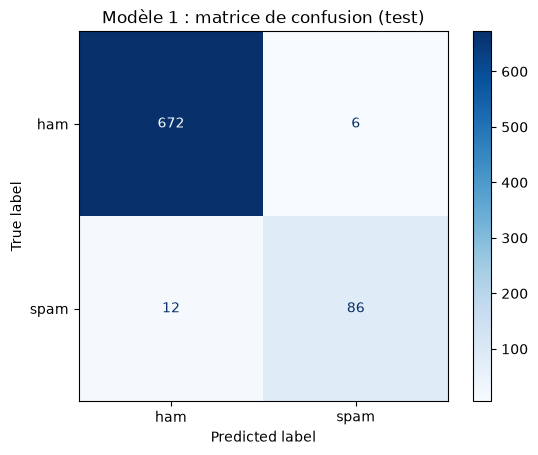

In [15]:
test_probas, y_test = predict(best_model, test_loader)
test_pred = (test_probas > 0.5).astype(int)

print(classification_report(y_test, test_pred, target_names=["ham", "spam"], digits=3))

ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=["ham", "spam"]).plot(cmap="Blues")
plt.title(f"{best_name} : matrice de confusion (test)")
plt.show()

In [16]:
final = scores(y_test, test_pred)
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(f"PERFORMANCE FINALE ({best_name}, jeu de test de {len(y_test)} SMS)")
print(f"- accuracy : {final['accuracy']:.1%} (référence « toujours ham » : {1 - y_test.mean():.1%})")
print(f"- précision spam : {final['précision (spam)']:.1%} : sur {tp + fp} SMS signalés spam, {tp} le sont vraiment")
print(f"- rappel spam : {final['rappel (spam)']:.1%} : sur {tp + fn} vrais spams, {tp} sont détectés")
print(f"- F1 spam : {final['F1 (spam)']:.3f}")
print(f"- {fp} SMS normaux classés à tort en spam, {fn} spams non détectés")

PERFORMANCE FINALE (Modèle 1, jeu de test de 776 SMS)
- accuracy : 97.7% (référence « toujours ham » : 87.4%)
- précision spam : 93.5% : sur 92 SMS signalés spam, 86 le sont vraiment
- rappel spam : 87.8% : sur 98 vrais spams, 86 sont détectés
- F1 spam : 0.905
- 6 SMS normaux classés à tort en spam, 12 spams non détectés


## 5. Analyse des erreurs

On regarde les SMS que le modèle retenu classe mal. Comme dans le cours, cela aide à comprendre ses limites.

In [17]:
errors = test_df.copy()
errors["proba_spam"] = test_probas
errors["prediction"] = test_pred
errors = errors[errors["prediction"] != errors["target"]]

pd.set_option("display.max_colwidth", 200)
print("Spams non détectés (faux négatifs) :")
display(errors[errors["target"] == 1][["text", "proba_spam"]].sort_values("proba_spam").head(10))
print("SMS normaux classés spam (faux positifs) :")
display(errors[errors["target"] == 0][["text", "proba_spam"]].sort_values("proba_spam", ascending=False).head(10))

Spams non détectés (faux négatifs) :


,text,proba_spam
849,Hello. We need some posh birds and chaps to user trial prods for champneys. Can i put you down? I need your address and dob asap. Ta r,0.046205
4220,Money i have won wining number 946 wot do i do next,0.161595
1644,"Free msg. Sorry, a service you ordered from 81303 could not be delivered as you do not have sufficient credit. Please top up to receive the service.",0.215570
1458,Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.,0.225195
3634,"Oh my god! I've found your number again! I'm so glad, text me back xafter this msgs cst std ntwk chg å£1.50",0.226816
1279,"Win the newest ÛÏHarry Potter and the Order of the Phoenix (Book 5) reply HARRY, answer 5 questions - chance to be the first among readers!",0.272668
2641,Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winner,0.314632
1994,Sexy Singles are waiting for you! Text your AGE followed by your GENDER as wither M or F E.G.23F. For gay men text your AGE followed by a G. e.g.23G.,0.445206
4363,"Customer service announcement. We recently tried to make a delivery to you but were unable to do so, please call 07099833605 to re-schedule. Ref:9280114",0.449860
2906,"Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603",0.451331


SMS normaux classés spam (faux positifs) :


,text,proba_spam
2888,Your bill at 3 is å£33.65 so thats not bad!,0.654820
3127,Ee msg na poortiyagi odalebeku: Hanumanji 7 name 1-Hanuman 2-Bajarangabali 3-Maruti 4-Pavanaputra 5-Sankatmochan 6-Ramaduth 7-Mahaveer ee 7 name &lt;#&gt; janarige ivatte kalisidare next saturda...,0.610244
237,PLEASSSSSSSEEEEEE TEL ME V AVENT DONE SPORTSx,0.566544
4896,\ER,0.537112
1252,"Hey...Great deal...Farm tour 9am to 5pm $95/pax, $50 deposit by 16 May",0.520754
1618,Lmao!nice 1,0.515709


## Conclusion

Les performances finales sont affichées dans la cellule « PERFORMANCE FINALE » ci-dessus. Pour un détecteur de spam, les deux erreurs n'ont pas le même coût : classer un SMS normal en spam fait perdre un message légitime à l'utilisateur, alors qu'un spam non détecté reste une nuisance. Le seuil de 0,5 peut être relevé ou abaissé selon ce que l'opérateur préfère éviter.

**Pistes d'amélioration** : tester des séquences plus longues, d'autres tailles d'embedding, un seuil de décision ajusté, ou des modèles pré-entraînés sur du texte (transfer learning).